In [1]:
!pip install pyarrow pandas matplotlib tqdm

   ---------------------------------------- 0.0/27.5 MB ? eta -:--:--
   ------ --------------------------------- 4.5/27.5 MB 26.9 MB/s eta 0:00:01
   --------------- ------------------------ 10.5/27.5 MB 28.5 MB/s eta 0:00:01
   ------------------------- -------------- 17.8/27.5 MB 31.3 MB/s eta 0:00:01
   ---------------------------------- ----- 23.6/27.5 MB 30.5 MB/s eta 0:00:01
   ---------------------------------------  27.3/27.5 MB 29.3 MB/s eta 0:00:01
   ---------------------------------------- 27.5/27.5 MB 27.3 MB/s  0:00:01


In [2]:
import pyarrow.parquet as pq

file_path = "../data/training_camera_image_10017090168044687777_6380_000_6400_000.parquet"

table = pq.read_table(file_path)
df = table.to_pandas()

print(df.columns)
print(len(df))
df.head()

Index(['key.segment_context_name', 'key.frame_timestamp_micros',
       'key.camera_name', '[CameraImageComponent].image',
       '[CameraImageComponent].pose.transform',
       '[CameraImageComponent].velocity.linear_velocity.x',
       '[CameraImageComponent].velocity.linear_velocity.y',
       '[CameraImageComponent].velocity.linear_velocity.z',
       '[CameraImageComponent].velocity.angular_velocity.x',
       '[CameraImageComponent].velocity.angular_velocity.y',
       '[CameraImageComponent].velocity.angular_velocity.z',
       '[CameraImageComponent].pose_timestamp',
       '[CameraImageComponent].rolling_shutter_params.shutter',
       '[CameraImageComponent].rolling_shutter_params.camera_trigger_time',
       '[CameraImageComponent].rolling_shutter_params.camera_readout_done_time'],
      dtype='object')
990


,key.segment_context_name,key.frame_timestamp_micros,key.camera_name,[CameraImageComponent].image,[CameraImageComponent].pose.transform,[CameraImageComponent].velocity.linear_velocity.x,[CameraImageComponent].velocity.linear_velocity.y,[CameraImageComponent].velocity.linear_velocity.z,[CameraImageComponent].velocity.angular_velocity.x,[CameraImageComponent].velocity.angular_velocity.y,[CameraImageComponent].velocity.angular_velocity.z,[CameraImageComponent].pose_timestamp,[CameraImageComponent].rolling_shutter_params.shutter,[CameraImageComponent].rolling_shutter_params.camera_trigger_time,[CameraImageComponent].rolling_shutter_params.camera_readout_done_time
index,,,,,,,,,,,,,,,
10017090168044687777_6380_000_6400_000;1550083467346370,10017090168044687777_6380_000_6400_000,1550083467346370,1,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,"[0.9482868309813268, -0.23495154098744556, 0.2...",5.765131,1.371270,-1.329111,-0.010016,-0.014922,0.105475,1.550083e+09,0.009992,1.550083e+09,1.550083e+09
10017090168044687777_6380_000_6400_000;1550083467346370,10017090168044687777_6380_000_6400_000,1550083467346370,2,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,"[0.9487161220058431, -0.23293730459068215, 0.2...",5.757565,1.392409,-1.327417,0.003401,-0.011684,0.099375,1.550083e+09,0.009992,1.550083e+09,1.550083e+09
10017090168044687777_6380_000_6400_000;1550083467346370,10017090168044687777_6380_000_6400_000,1550083467346370,4,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,"[0.9489391880311817, -0.23197163266142976, 0.2...",5.762588,1.389895,-1.330847,0.005329,-0.012516,0.098726,1.550083e+09,0.009992,1.550083e+09,1.550083e+09
10017090168044687777_6380_000_6400_000;1550083467346370,10017090168044687777_6380_000_6400_000,1550083467346370,3,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,"[0.9480805733268344, -0.23597955012227076, 0.2...",5.764107,1.374694,-1.330062,-0.014756,-0.016971,0.102667,1.550083e+09,0.009992,1.550083e+09,1.550083e+09
10017090168044687777_6380_000_6400_000;1550083467346370,10017090168044687777_6380_000_6400_000,1550083467346370,5,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,"[0.9479157488563362, -0.23691579285250022, 0.2...",5.758528,1.381121,-1.324764,-0.016695,-0.015307,0.097743,1.550083e+09,0.009992,1.550083e+09,1.550083e+09


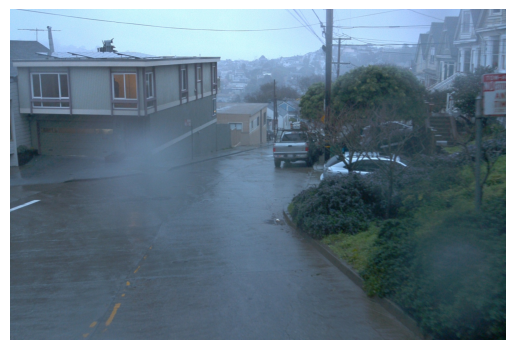

In [3]:
from PIL import Image
import io
import matplotlib.pyplot as plt


row = df.iloc[0]

image_bytes = row['[CameraImageComponent].image']

# decode
image = Image.open(io.BytesIO(image_bytes))

plt.imshow(image)
plt.axis('off')
plt.show()

In [5]:
#Try saving frames to the outputs
camera_map = {
    1: "front",
    2: "front_left",
    3: "front_right",
    4: "side_left",
    5: "side_right"
}
timestamp = df.iloc[0]['key.frame_timestamp_micros']
frame_df = df[df['key.frame_timestamp_micros'] == timestamp]
import os

save_dir = "../outputs/experiment_outputs/frame_000"
os.makedirs(save_dir, exist_ok=True)

for _, row in frame_df.iterrows():
    cam_id = row['key.camera_name']
    cam_name = camera_map[cam_id]
    
    image_bytes = row['[CameraImageComponent].image']
    image = Image.open(io.BytesIO(image_bytes))
    
    save_path = os.path.join(save_dir, f"{cam_name}.jpg")
    image.save(save_path)


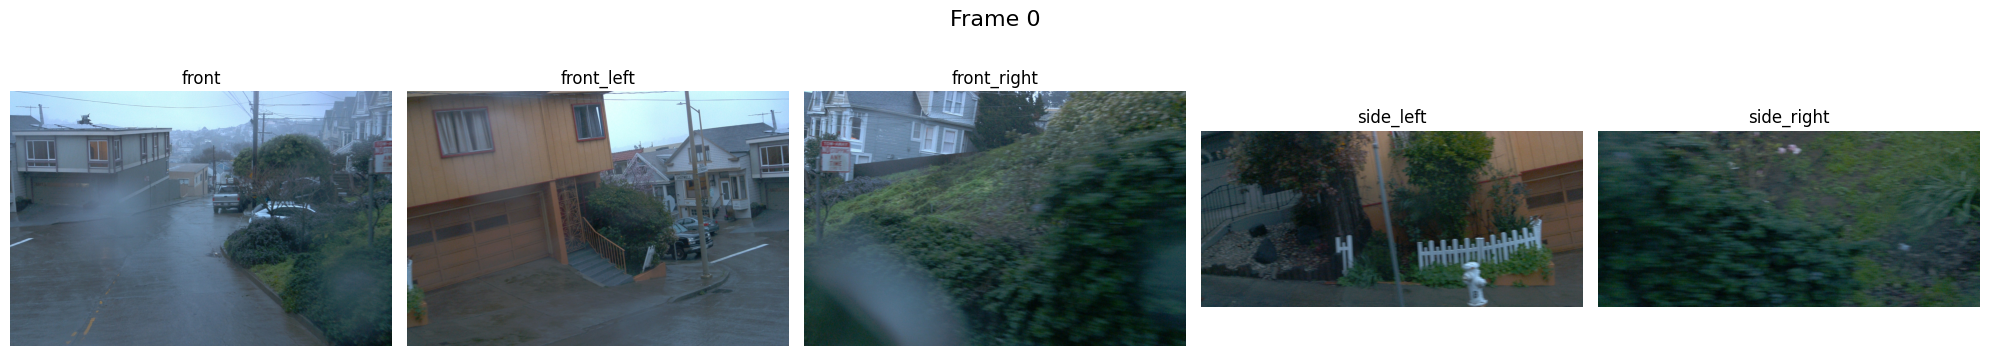

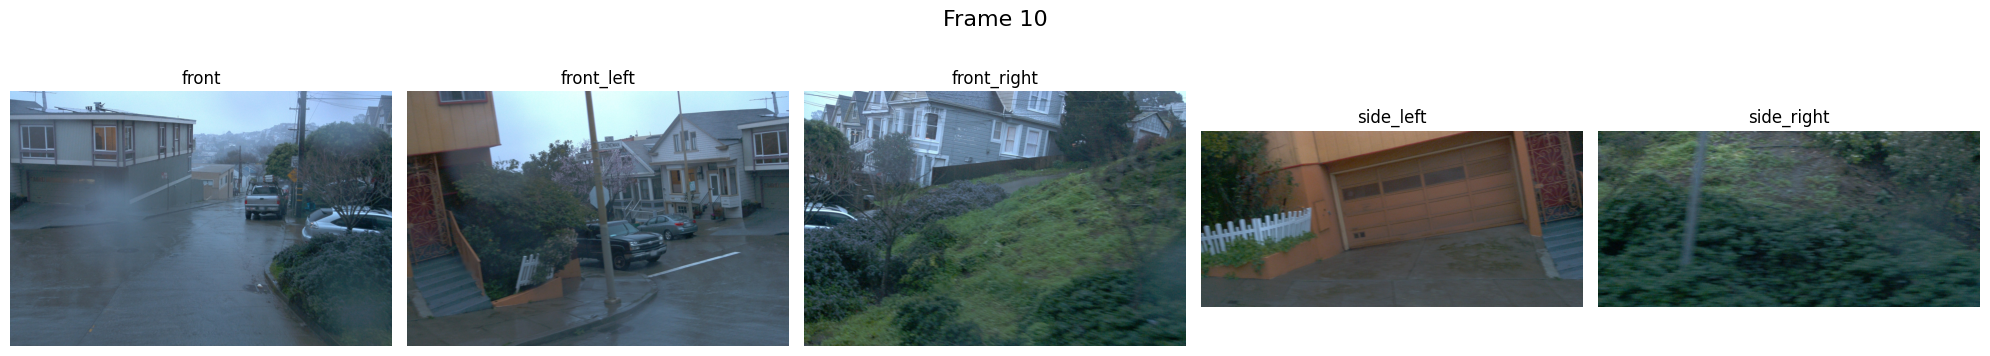

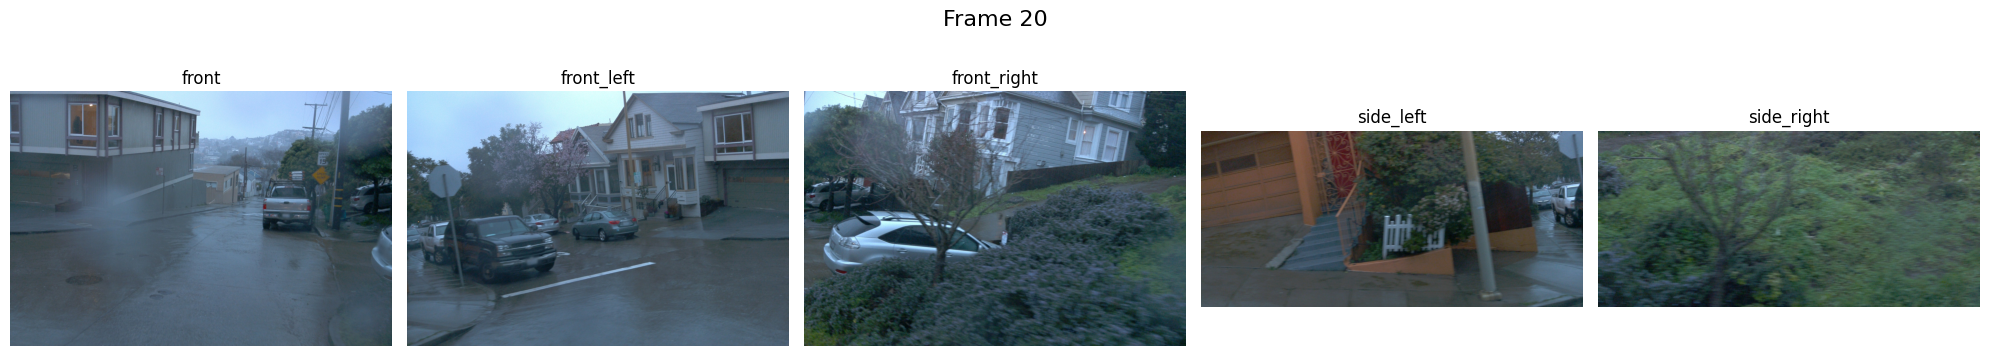

In [7]:
import matplotlib.pyplot as plt
from PIL import Image
import io

# camera id → name
camera_map = {
    1: "front",
    2: "front_left",
    3: "front_right",
    4: "side_left",
    5: "side_right"
}

timestamps = df['key.frame_timestamp_micros'].unique()

for i in [0, 10, 20]:
    timestamp = timestamps[i]

    frame_df = df[df['key.frame_timestamp_micros'] == timestamp]
    frame_df = frame_df.sort_values('key.camera_name')  

    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    fig.suptitle(f"Frame {i}", fontsize=16)

    for j, (_, row) in enumerate(frame_df.iterrows()):
        cam_id = row['key.camera_name']
        cam_name = camera_map[cam_id]

        image_bytes = row['[CameraImageComponent].image']
        image = Image.open(io.BytesIO(image_bytes))

        axes[j].imshow(image)
        axes[j].set_title(cam_name)
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()